In [1]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║          SAC  ·  LunarLander-v2 (continuous)  ·  TRAINING      ║
# ╚══════════════════════════════════════════════════════════════════╝
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.tensorboard import SummaryWriter
from datetime import datetime
import copy

# ── Config ────────────────────────────────────────────────────────────────────
STATE_DIM  = 8
ACTION_DIM = 2
MAX_ACTION = 1.0

learning_rate   = 3e-4
gamma           = 0.99
tau             = 0.005    # soft update coefficient
alpha_init      = 0.2      # initial entropy temperature (auto-tuned)
batch_size      = 256
buffer_size     = 1_000_000
start_episodes  = 30       # random exploration before training (episodes)
TOTAL_EPISODES  = 4000
EVAL_INTERVAL   = 50       # evaluation period (episodes)
SAVE_INTERVAL   = 500      # FINAL_PATH 덮어쓰기 주기 (episodes)
N_EVAL_EPISODES = 5

FINAL_PATH = 'sac_lunar_lander_final.pt'
BEST_PATH  = 'sac_lunar_lander_best.pt'
LOG_DIR    = f'runs/SAC_lunar_lander_{datetime.now().strftime("%Y%m%d_%H%M%S")}'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
print(f'CUDA   : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
print(f'Log dir: {LOG_DIR}')

# ── Replay Buffer ─────────────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self):
        self.ptr  = 0
        self.size = 0
        self.s  = np.zeros((buffer_size, STATE_DIM),  dtype=np.float32)
        self.a  = np.zeros((buffer_size, ACTION_DIM), dtype=np.float32)
        self.r  = np.zeros((buffer_size, 1),          dtype=np.float32)
        self.s_ = np.zeros((buffer_size, STATE_DIM),  dtype=np.float32)
        self.d  = np.zeros((buffer_size, 1),          dtype=np.float32)

    def add(self, s, a, r, s_, done):
        self.s[self.ptr]  = s
        self.a[self.ptr]  = a
        self.r[self.ptr]  = r
        self.s_[self.ptr] = s_
        self.d[self.ptr]  = done
        self.ptr  = (self.ptr + 1) % buffer_size
        self.size = min(self.size + 1, buffer_size)

    def sample(self):
        idx = np.random.randint(0, self.size, batch_size)
        return (
            torch.FloatTensor(self.s[idx]).to(device),
            torch.FloatTensor(self.a[idx]).to(device),
            torch.FloatTensor(self.r[idx]).to(device),
            torch.FloatTensor(self.s_[idx]).to(device),
            torch.FloatTensor(self.d[idx]).to(device),
        )

# ── Actor (Stochastic) ────────────────────────────────────────────────────────
class Actor(nn.Module):
    LOG_STD_MIN = -20
    LOG_STD_MAX =   2

    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(STATE_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
        )
        self.mean_layer    = nn.Linear(256, ACTION_DIM)
        self.log_std_layer = nn.Linear(256, ACTION_DIM)

    def forward(self, s):
        x       = self.shared(s)
        mean    = self.mean_layer(x)
        log_std = self.log_std_layer(x).clamp(self.LOG_STD_MIN, self.LOG_STD_MAX)
        return mean, log_std

    def sample(self, s):
        """Reparameterization trick + tanh squashing."""
        mean, log_std = self.forward(s)
        std    = log_std.exp()
        eps    = torch.randn_like(mean)
        x      = mean + std * eps
        a      = torch.tanh(x)
        log_prob = (
            torch.distributions.Normal(mean, std).log_prob(x)
            - torch.log(1 - a.pow(2) + 1e-6)
        ).sum(dim=-1, keepdim=True)
        return MAX_ACTION * a, log_prob

    def deterministic_action(self, s):
        mean, _ = self.forward(s)
        return MAX_ACTION * torch.tanh(mean)

# ── Critic (Twin Q-networks) ──────────────────────────────────────────────────
class Critic(nn.Module):
    def __init__(self):
        super().__init__()
        self.q1 = nn.Sequential(
            nn.Linear(STATE_DIM + ACTION_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),                    nn.ReLU(),
            nn.Linear(256, 1),
        )
        self.q2 = nn.Sequential(
            nn.Linear(STATE_DIM + ACTION_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),                    nn.ReLU(),
            nn.Linear(256, 1),
        )

    def forward(self, s, a):
        sa = torch.cat([s, a], dim=1)
        return self.q1(sa), self.q2(sa)

# ── SAC Agent ─────────────────────────────────────────────────────────────────
class SACAgent:
    def __init__(self):
        self.actor     = Actor().to(device)
        self.actor_opt = optim.Adam(self.actor.parameters(), lr=learning_rate)

        self.critic        = Critic().to(device)
        self.critic_target = copy.deepcopy(self.critic)
        self.critic_opt    = optim.Adam(self.critic.parameters(), lr=learning_rate)

        self.target_entropy = -float(ACTION_DIM)
        self.log_alpha      = torch.tensor(np.log(alpha_init), dtype=torch.float,
                                           requires_grad=True, device=device)
        self.alpha          = self.log_alpha.exp().item()
        self.alpha_opt      = optim.Adam([self.log_alpha], lr=learning_rate)

    def select_action(self, s, evaluate=False):
        s = torch.FloatTensor(s).unsqueeze(0).to(device)
        if evaluate:
            return self.actor.deterministic_action(s).cpu().data.numpy().flatten()
        a, _ = self.actor.sample(s)
        return a.cpu().data.numpy().flatten()

    def update(self, buf):
        s, a, r, s_, d = buf.sample()

        # ── Critic update ─────────────────────────────────────────────────────
        with torch.no_grad():
            a_, log_prob_ = self.actor.sample(s_)
            q1_, q2_      = self.critic_target(s_, a_)
            q_target = r + gamma * (1 - d) * (torch.min(q1_, q2_) - self.alpha * log_prob_)

        q1, q2      = self.critic(s, a)
        critic_loss = F.mse_loss(q1, q_target) + F.mse_loss(q2, q_target)
        self.critic_opt.zero_grad()
        critic_loss.backward()
        self.critic_opt.step()

        # ── Actor update ──────────────────────────────────────────────────────
        a_new, log_prob = self.actor.sample(s)
        q1_new, q2_new  = self.critic(s, a_new)
        actor_loss = (self.alpha * log_prob - torch.min(q1_new, q2_new)).mean()
        self.actor_opt.zero_grad()
        actor_loss.backward()
        self.actor_opt.step()

        # ── Temperature (α) update ────────────────────────────────────────────
        alpha_loss = -(self.log_alpha * (log_prob.detach() + self.target_entropy)).mean()
        self.alpha_opt.zero_grad()
        alpha_loss.backward()
        self.alpha_opt.step()
        self.alpha = self.log_alpha.exp().item()

        # ── Soft update critic target ──────────────────────────────────────────
        for p, tp in zip(self.critic.parameters(), self.critic_target.parameters()):
            tp.data.copy_(tau * p.data + (1 - tau) * tp.data)

        return critic_loss.item(), actor_loss.item(), alpha_loss.item(), self.alpha

    def save(self, path):
        torch.save({
            'actor':         self.actor.state_dict(),
            'critic':        self.critic.state_dict(),
            'critic_target': self.critic_target.state_dict(),
            'log_alpha':     self.log_alpha.item(),
        }, path)

    def load(self, path):
        ckpt = torch.load(path, map_location=device)
        self.actor.load_state_dict(ckpt['actor'])
        self.critic.load_state_dict(ckpt['critic'])
        self.critic_target.load_state_dict(ckpt['critic_target'])
        self.log_alpha = torch.tensor(ckpt['log_alpha'], requires_grad=True, device=device)
        self.alpha     = self.log_alpha.exp().item()

# ── Evaluation (deterministic, no render) ────────────────────────────────────
def evaluate(agent):
    eval_env = gym.make('LunarLander-v2', continuous=True)
    rewards  = []
    for _ in range(N_EVAL_EPISODES):
        s, _  = eval_env.reset()
        done  = False
        ep_r  = 0.0
        while not done:
            a            = agent.select_action(s, evaluate=True)
            s, r, done, truncated, _ = eval_env.step(a)
            done         = done or truncated
            ep_r        += r
        rewards.append(ep_r)
    eval_env.close()
    return float(np.mean(rewards))

# ── Main Training Loop ────────────────────────────────────────────────────────
def main():
    env    = gym.make('LunarLander-v2', continuous=True)
    buf    = ReplayBuffer()
    agent  = SACAgent()
    writer = SummaryWriter(log_dir=LOG_DIR)

    best_eval = float('-inf')

    print(f'\n{"="*60}')
    print(f'  SAC  |  LunarLander-v2 continuous')
    print(f'  Total episodes   : {TOTAL_EPISODES:,}')
    print(f'  Random explore   : first {start_episodes} episodes')
    print(f'  Eval interval    : every {EVAL_INTERVAL} episodes  ({N_EVAL_EPISODES} episodes)')
    print(f'  Target entropy   : {-float(ACTION_DIM):.1f}')
    print(f'{"="*60}')

    for n_epi in range(TOTAL_EPISODES):
        s, _        = env.reset()
        ep_reward   = 0.0
        ep_c_losses = []
        ep_a_losses = []
        ep_al_losses = []

        while True:
            # ── Action selection ──────────────────────────────────────────────
            if n_epi < start_episodes:
                a = env.action_space.sample()
            else:
                a = agent.select_action(s)

            s_, r, done, truncated, _ = env.step(a)
            terminal   = done or truncated
            ep_reward += r

            # done=True only for true termination (not time limit) for Bellman bootstrapping
            buf.add(s, a, r, s_, float(done))
            s = s_

            # ── Network update ────────────────────────────────────────────────
            if n_epi >= start_episodes and buf.size >= batch_size:
                c_loss, a_loss, al_loss, alpha = agent.update(buf)
                ep_c_losses.append(c_loss)
                ep_a_losses.append(a_loss)
                ep_al_losses.append(al_loss)

            if terminal:
                break

        # ── Episode end ───────────────────────────────────────────────────────
        writer.add_scalar('Reward/episode', ep_reward, n_epi)
        if ep_c_losses:
            writer.add_scalar('Loss/critic', np.mean(ep_c_losses),  n_epi)
            writer.add_scalar('Loss/actor',  np.mean(ep_a_losses),  n_epi)
            writer.add_scalar('Loss/alpha',  np.mean(ep_al_losses), n_epi)
            writer.add_scalar('Param/alpha', agent.alpha,           n_epi)

        if n_epi % 10 == 0:
            print(f'  epi {n_epi:5d} | reward {ep_reward:8.1f} | α {agent.alpha:.4f}')

        # ── Evaluation ───────────────────────────────────────────────────────
        if n_epi >= start_episodes and n_epi % EVAL_INTERVAL == 0:
            avg_r = evaluate(agent)
            writer.add_scalar('Reward/eval', avg_r, n_epi)
            print(f'  [eval]  epi {n_epi:5d} | avg reward ({N_EVAL_EPISODES} ep): {avg_r:8.1f} | α {agent.alpha:.4f}')
            if avg_r > best_eval:
                best_eval = avg_r
                agent.save(BEST_PATH)
                print(f'  [best]  {best_eval:.1f} -> {BEST_PATH}')
            writer.add_scalar('Reward/best', best_eval, n_epi)

        # ── Periodic save ─────────────────────────────────────────────────────
        if n_epi % SAVE_INTERVAL == 0 and n_epi != 0:
            agent.save(FINAL_PATH)
            print(f'  [saved] epi {n_epi:,} -> {FINAL_PATH}')

    env.close()
    writer.close()
    agent.save(FINAL_PATH)
    print(f'\nTraining done.')
    print(f'  Final -> {FINAL_PATH}')
    print(f'  Best  -> {BEST_PATH}  (eval reward: {best_eval:.1f})')
    print(f'  TensorBoard: tensorboard --logdir {LOG_DIR}')

main()

Device : cuda
CUDA   : True
GPU    : NVIDIA GeForce RTX 4090
Log dir: runs/SAC_lunar_lander_20260517_003446

  SAC  |  LunarLander-v2 continuous
  Total episodes   : 4,000
  Random explore   : first 30 episodes
  Eval interval    : every 50 episodes  (5 episodes)
  Target entropy   : -2.0
  epi     0 | reward   -244.6 | α 0.2000
  epi    10 | reward    -72.9 | α 0.2000
  epi    20 | reward   -306.5 | α 0.2000
  epi    30 | reward   -219.6 | α 0.1944
  epi    40 | reward    -94.4 | α 0.1142
  epi    50 | reward    -66.4 | α 0.1295
  [eval]  epi    50 | avg reward (5 ep):   -535.2 | α 0.1295
  [best]  -535.2 -> sac_lunar_lander_best.pt
  epi    60 | reward   -175.4 | α 0.1126
  epi    70 | reward    194.9 | α 0.0900
  epi    80 | reward     16.6 | α 0.1141
  epi    90 | reward   -195.6 | α 0.1084
  epi   100 | reward    144.5 | α 0.0924
  [eval]  epi   100 | avg reward (5 ep):    -55.3 | α 0.0924
  [best]  -55.3 -> sac_lunar_lander_best.pt
  epi   110 | reward    -31.9 | α 0.0871
  epi  

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_30968\2396277408.py:49: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt  = torch.load(save_path, map_location=devi

[final] actor loaded from sac_lunar_lander_final.pt
  saved α (entropy temperature): 0.0386
Running 5 episodes (deterministic)...

Episode  1/5 | reward:    257.1 | steps: 170


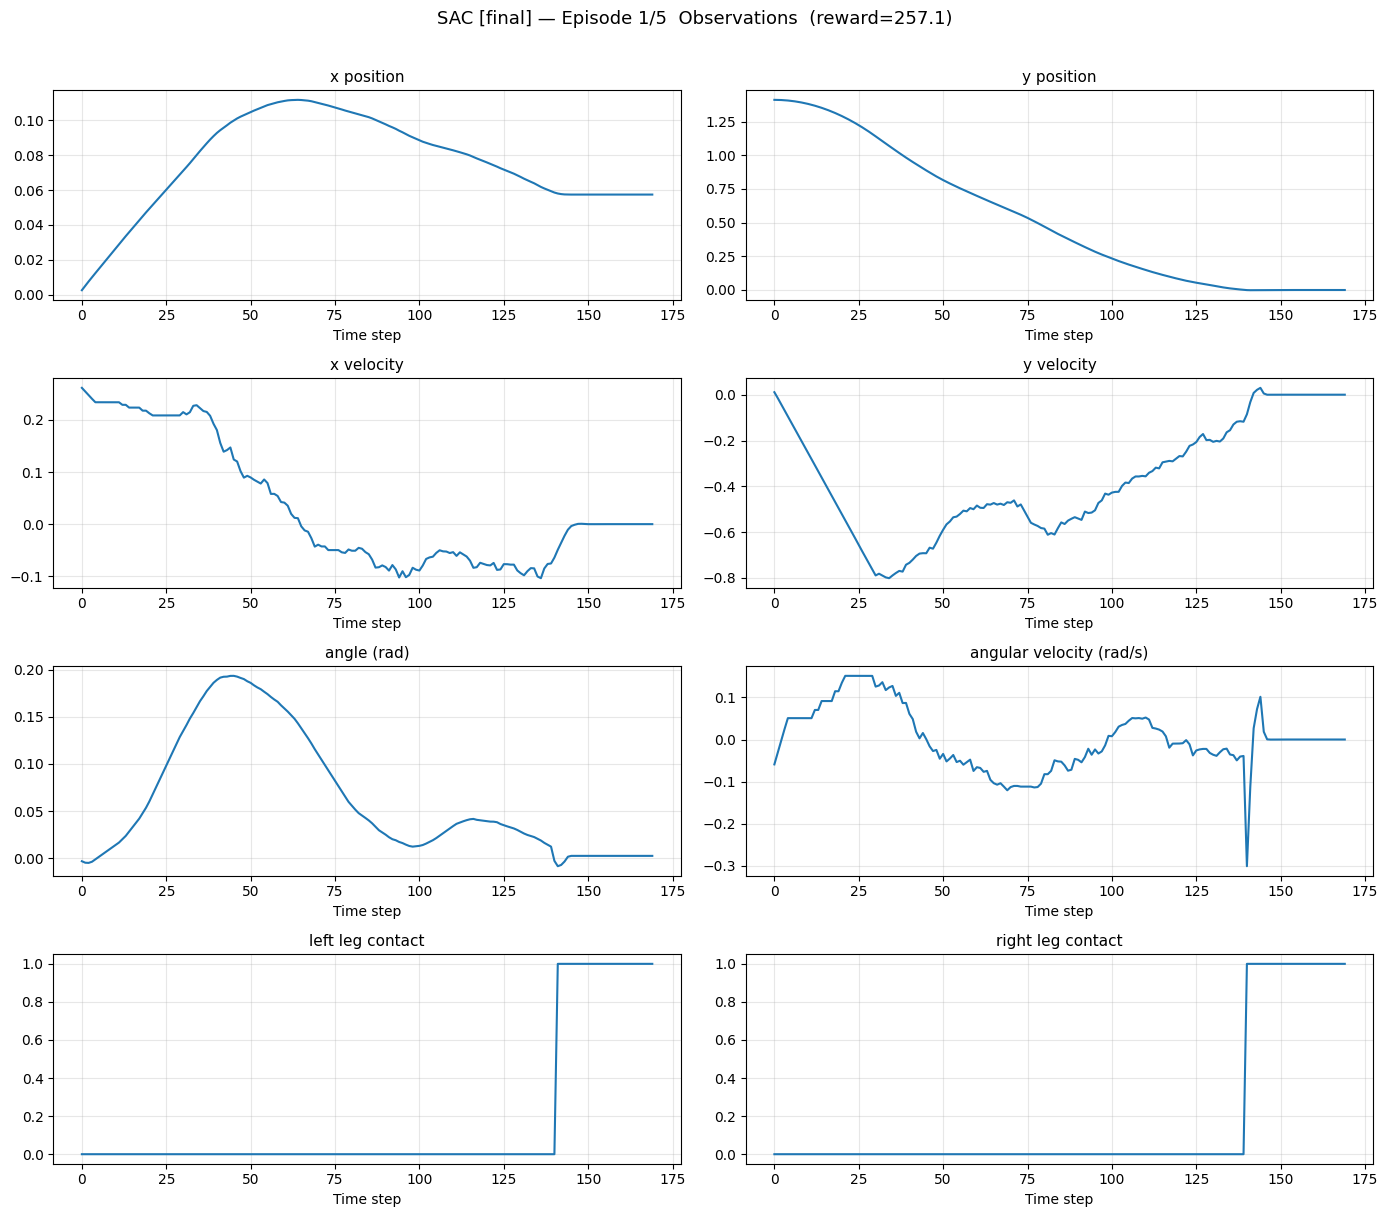

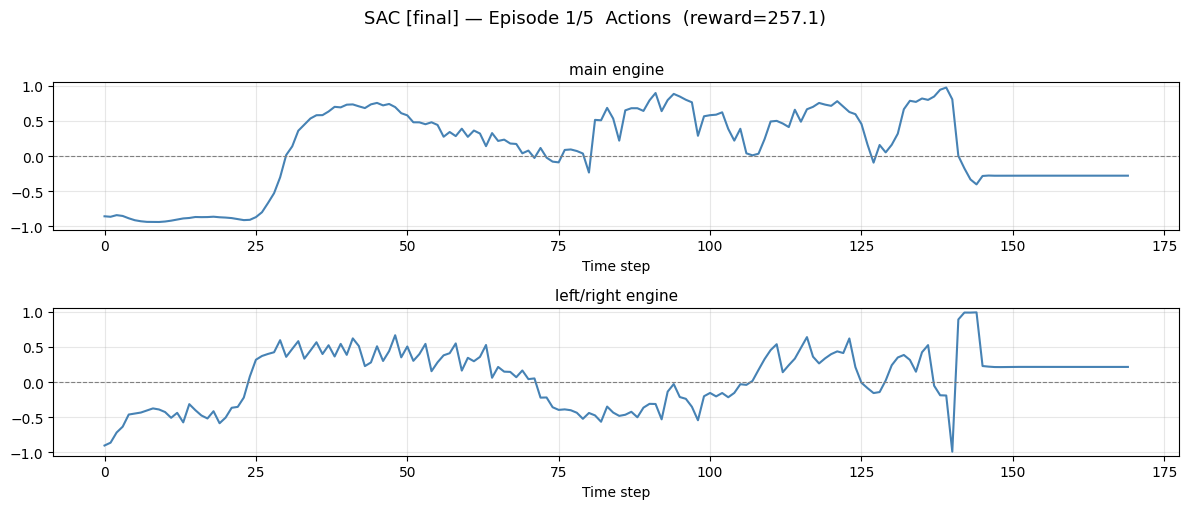

  Obs  plot -> sac_final_obs_ep1.png
  Act  plot -> sac_final_act_ep1.png

Episode  2/5 | reward:    303.5 | steps: 212


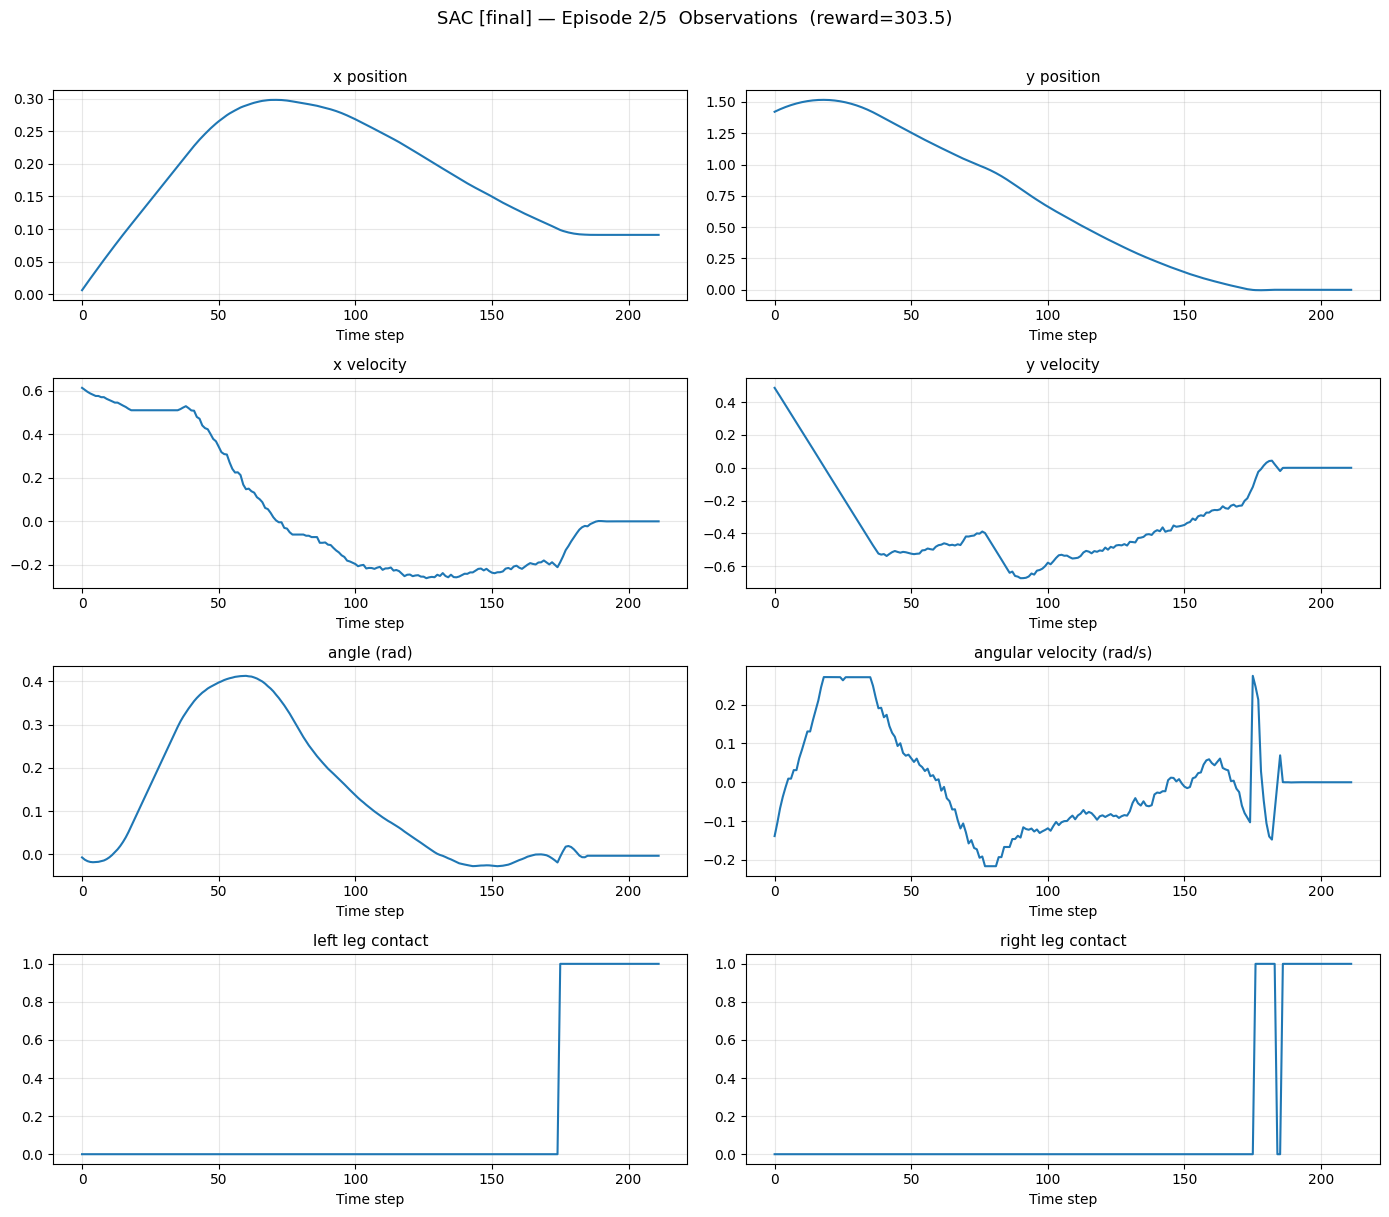

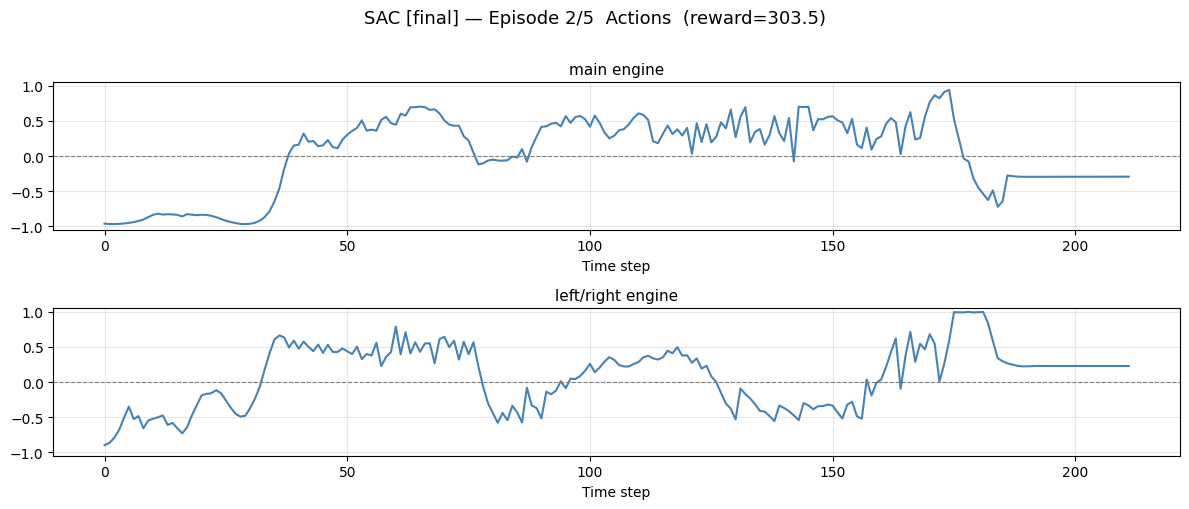

  Obs  plot -> sac_final_obs_ep2.png
  Act  plot -> sac_final_act_ep2.png

Episode  3/5 | reward:    295.5 | steps: 194


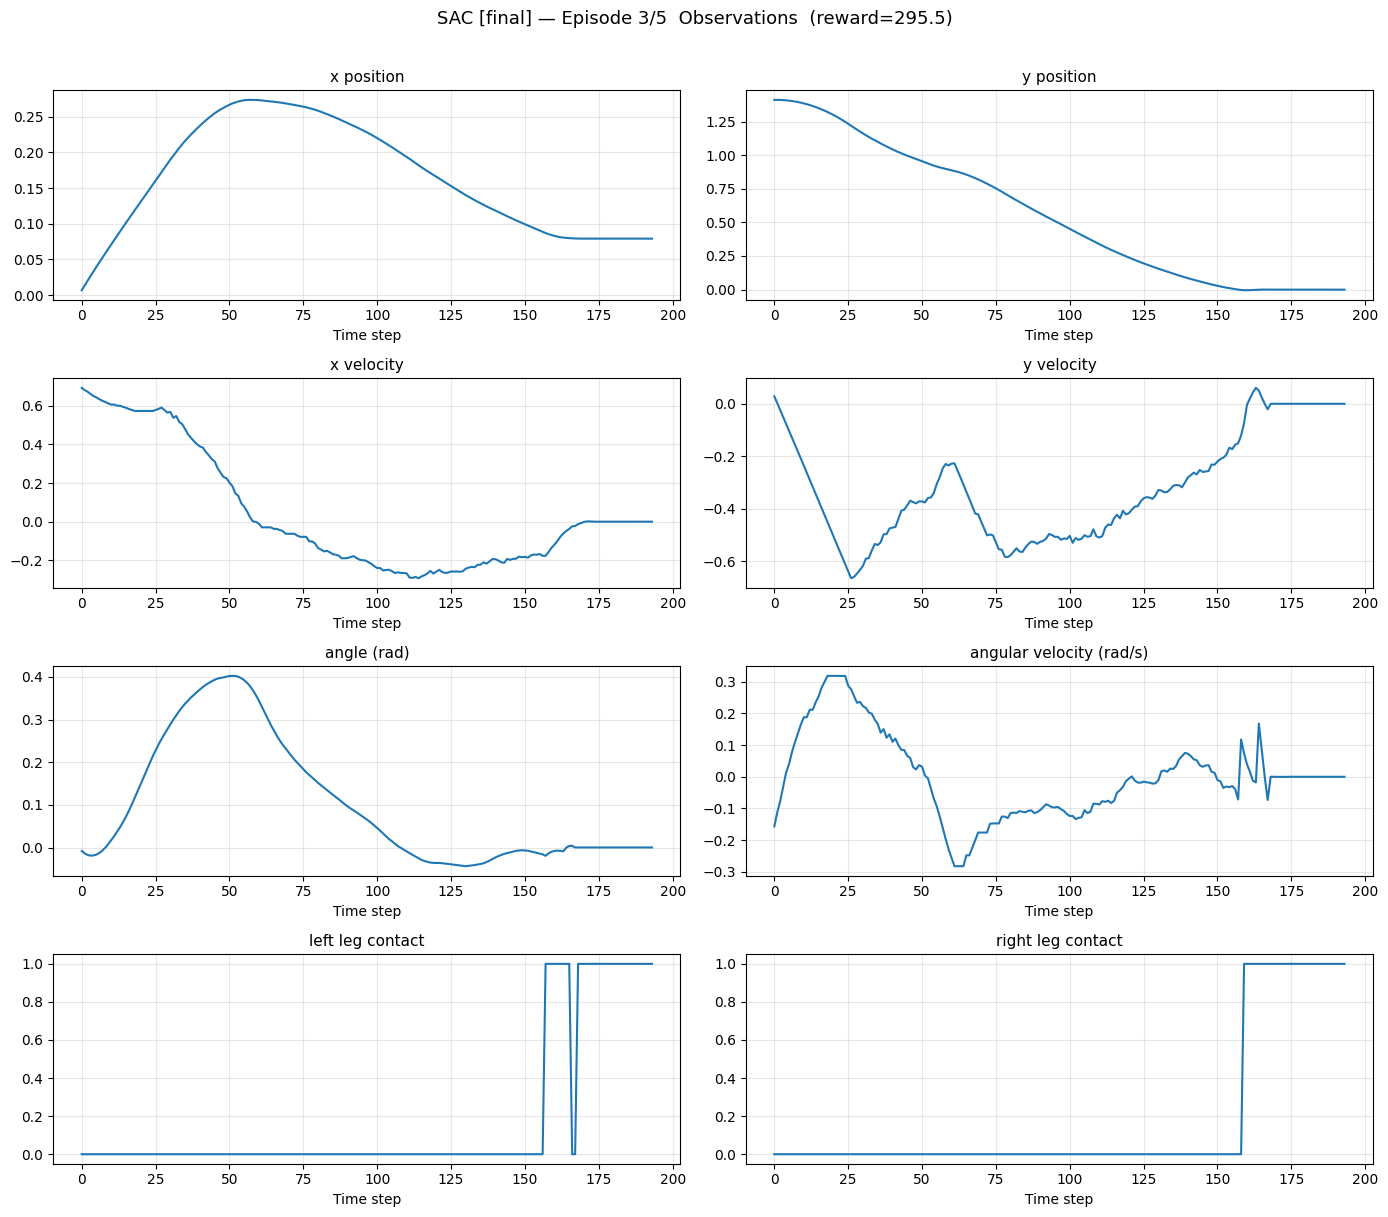

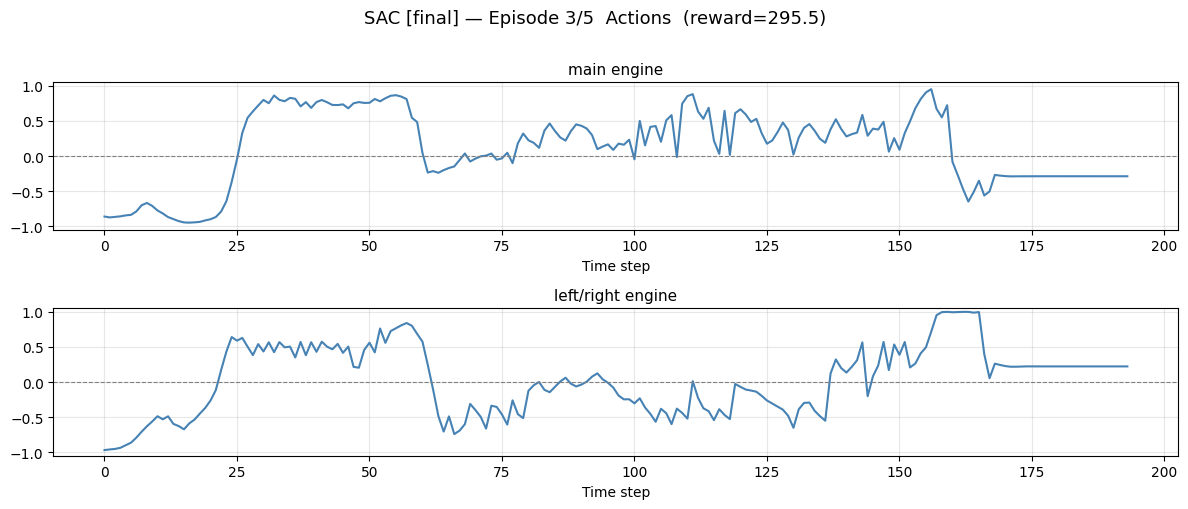

  Obs  plot -> sac_final_obs_ep3.png
  Act  plot -> sac_final_act_ep3.png

Episode  4/5 | reward:    256.3 | steps: 160


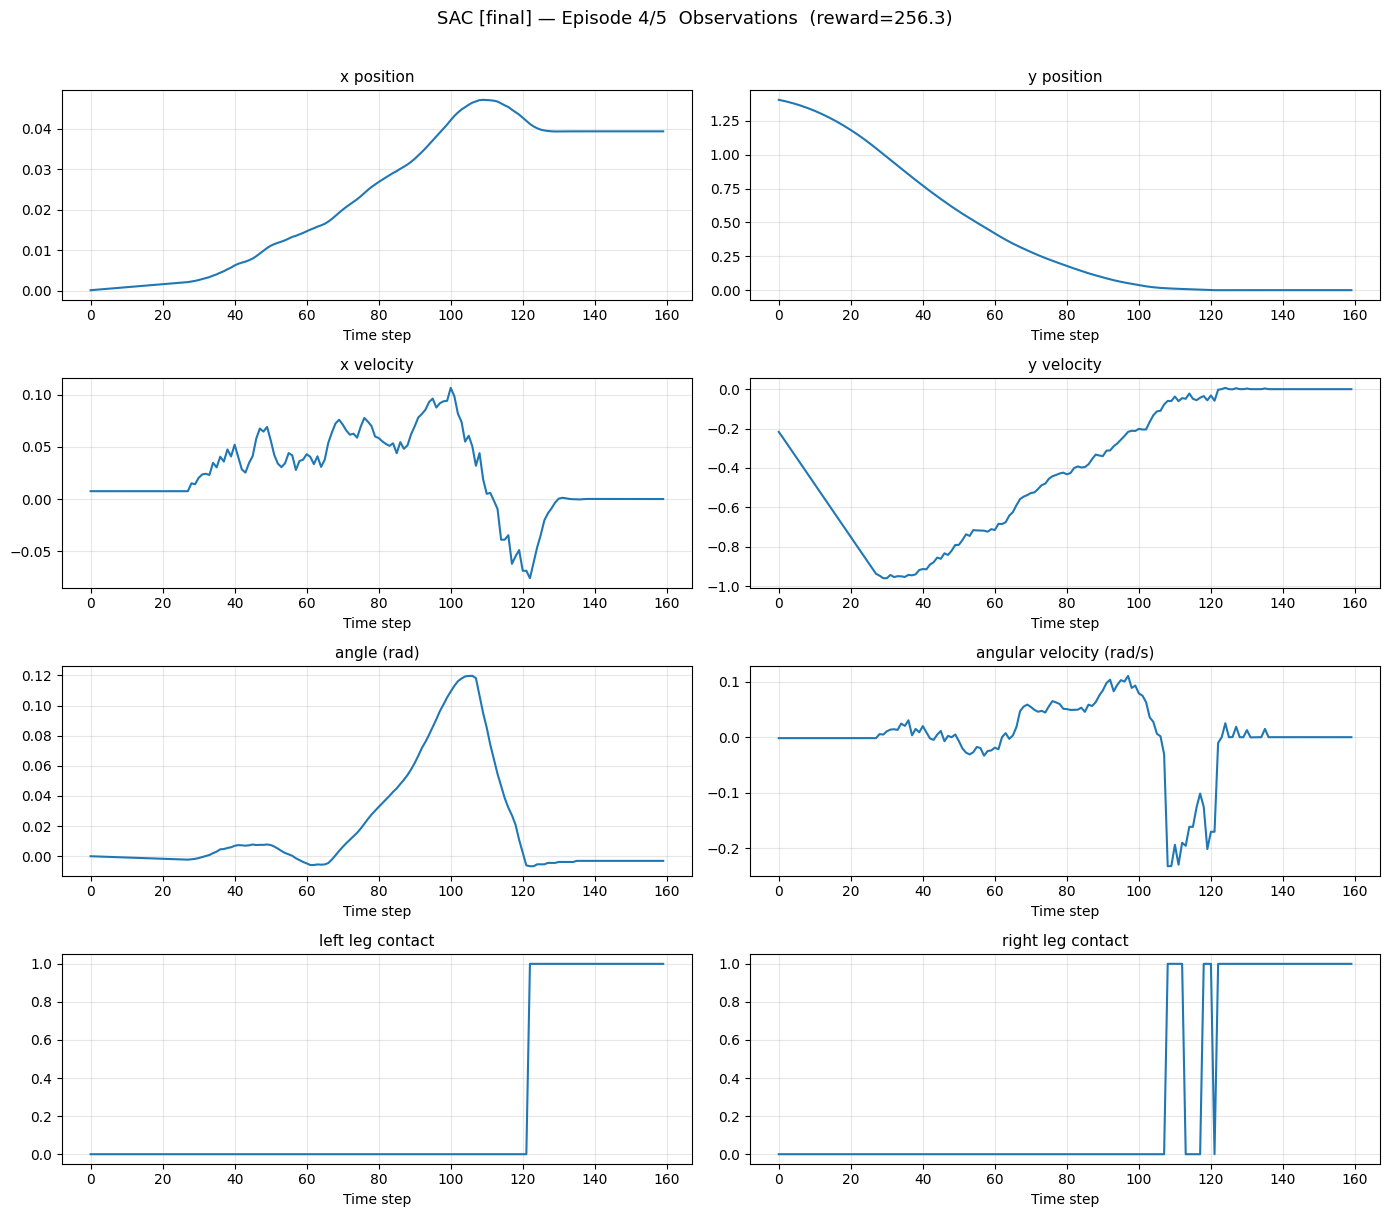

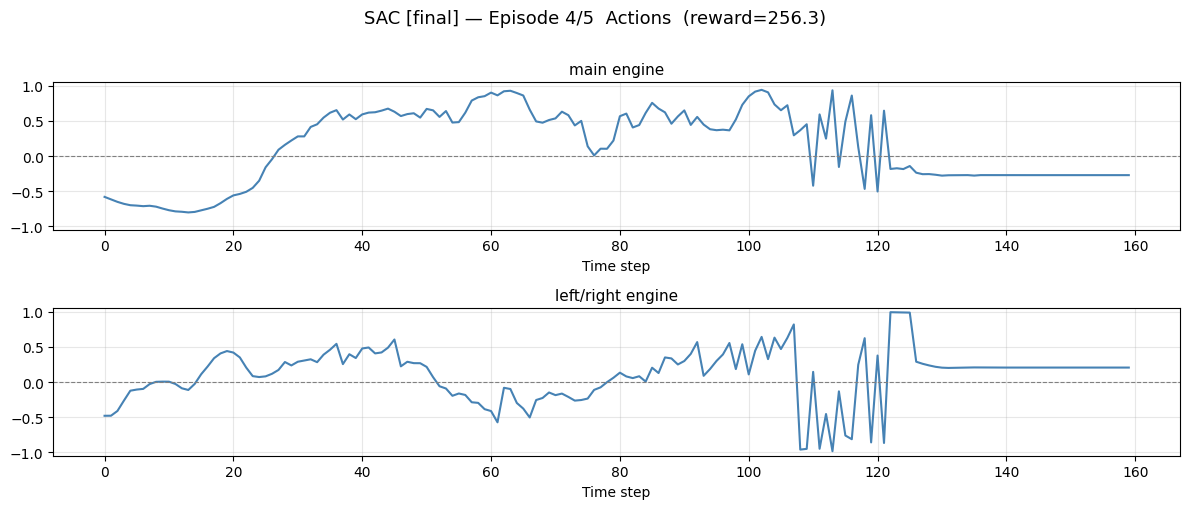

  Obs  plot -> sac_final_obs_ep4.png
  Act  plot -> sac_final_act_ep4.png

Episode  5/5 | reward:    299.3 | steps: 163


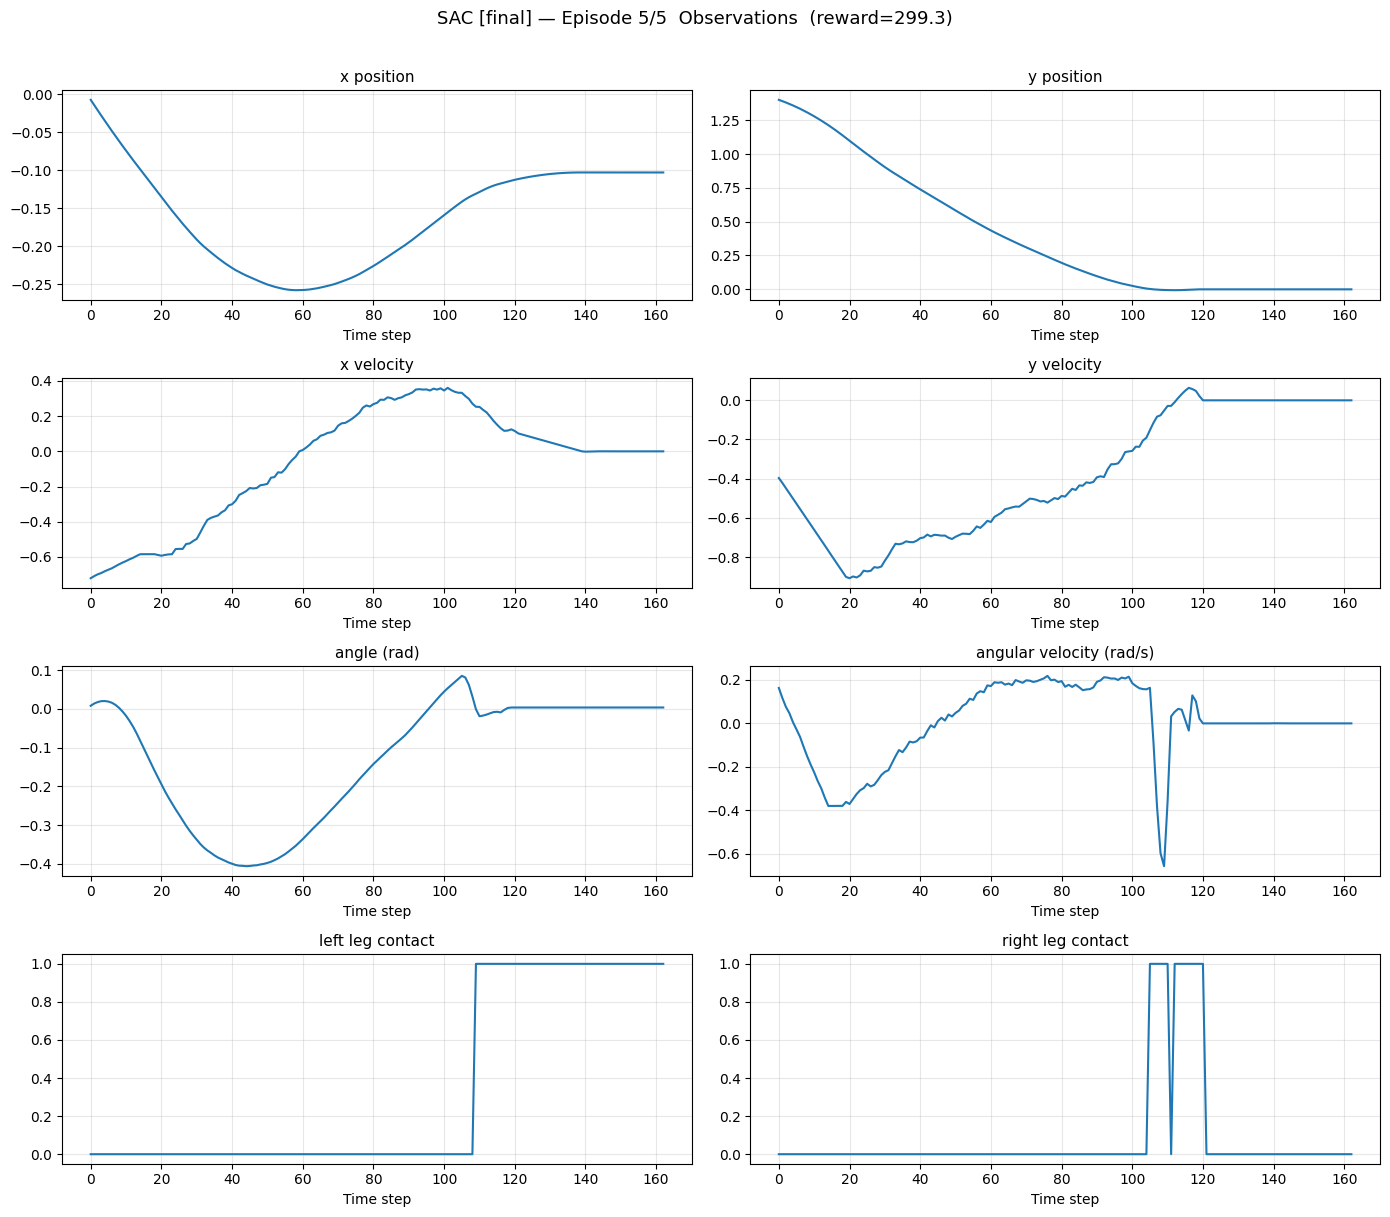

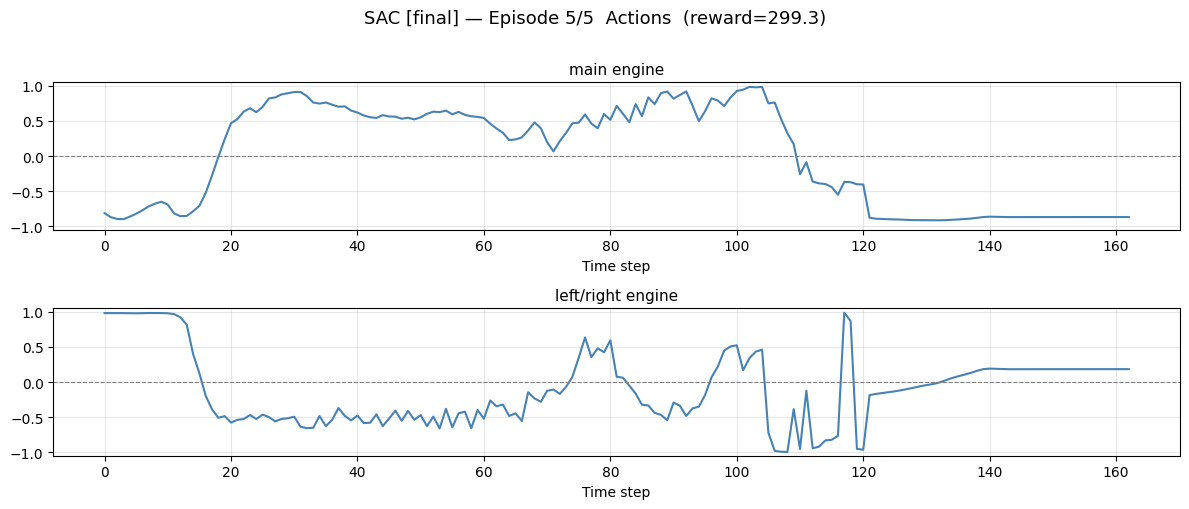

  Obs  plot -> sac_final_obs_ep5.png
  Act  plot -> sac_final_act_ep5.png

Done.


In [3]:
# ╔══════════════════════════════════════════════════════════════════╗
# ║          SAC  ·  LunarLander-v2 (continuous)  ·  INFERENCE     ║
# ╚══════════════════════════════════════════════════════════════════╝
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ── Config (must match training) ──────────────────────────────────────────────
STATE_DIM  = 8
ACTION_DIM = 2
MAX_ACTION = 1.0

FINAL_PATH = 'sac_lunar_lander_final.pt'
BEST_PATH  = 'sac_lunar_lander_best.pt'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# ── Actor (must match training) ───────────────────────────────────────────────
class Actor(nn.Module):
    LOG_STD_MIN = -20
    LOG_STD_MAX =   2

    def __init__(self):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(STATE_DIM, 256), nn.ReLU(),
            nn.Linear(256, 256),       nn.ReLU(),
        )
        self.mean_layer    = nn.Linear(256, ACTION_DIM)
        self.log_std_layer = nn.Linear(256, ACTION_DIM)

    def deterministic_action(self, s):
        x       = self.shared(s)
        mean    = self.mean_layer(x)
        return MAX_ACTION * torch.tanh(mean)

# ── Inference ─────────────────────────────────────────────────────────────────
def run_inference(save_path=FINAL_PATH, n_episodes=5):
    """
    save_path : FINAL_PATH (default) 또는 BEST_PATH
    n_episodes: 렌더링할 에피소드 수
    추론 시 결정론적 행동(mean of policy)을 사용합니다.
    """
    env = gym.make('LunarLander-v2', continuous=True, render_mode='human')

    actor = Actor().to(device)
    ckpt  = torch.load(save_path, map_location=device)
    actor.load_state_dict(ckpt['actor'])
    actor.eval()

    model_tag = 'final' if save_path == FINAL_PATH else 'best'
    saved_alpha = np.exp(ckpt['log_alpha'])
    print(f'[{model_tag}] actor loaded from {save_path}')
    print(f'  saved α (entropy temperature): {saved_alpha:.4f}')
    print(f'Running {n_episodes} episodes (deterministic)...\n')

    var_labels = [
        'x position',        'y position',
        'x velocity',        'y velocity',
        'angle (rad)',        'angular velocity (rad/s)',
        'left leg contact',  'right leg contact',
    ]
    action_labels = ['main engine', 'left/right engine']

    for ep in range(n_episodes):
        s, _         = env.reset()
        done         = False
        obs_history  = []
        act_history  = []
        total_reward = 0.0

        with torch.no_grad():
            while not done:
                obs_history.append(s.copy())
                s_t  = torch.FloatTensor(s).unsqueeze(0).to(device)
                a    = actor.deterministic_action(s_t).cpu().numpy().flatten()
                act_history.append(a.copy())
                s, r, done, truncated, _ = env.step(a)
                done = done or truncated
                total_reward += r

        steps = len(obs_history)
        print(f'Episode {ep+1:2d}/{n_episodes} | reward: {total_reward:8.1f} | steps: {steps}')

        obs = np.array(obs_history)   # (T, 8)
        act = np.array(act_history)   # (T, 2)
        t   = np.arange(steps)

        # ── Observation plot (4×2) ────────────────────────────────────────────
        fig, axes = plt.subplots(4, 2, figsize=(14, 12))
        for ax, col, label in zip(axes.flatten(), range(8), var_labels):
            ax.plot(t, obs[:, col], linewidth=1.5)
            ax.set_title(label, fontsize=11)
            ax.set_xlabel('Time step')
            ax.grid(True, alpha=0.3)
        plt.suptitle(
            f'SAC [{model_tag}] — Episode {ep+1}/{n_episodes}  Observations  (reward={total_reward:.1f})',
            fontsize=13, y=1.01
        )
        plt.tight_layout()
        obs_path = f'sac_{model_tag}_obs_ep{ep+1}.png'
        plt.savefig(obs_path, dpi=150, bbox_inches='tight')
        plt.show()

        # ── Action plot (2×1) ─────────────────────────────────────────────────
        fig, axes = plt.subplots(2, 1, figsize=(12, 5))
        for ax, col, label in zip(axes, range(2), action_labels):
            ax.plot(t, act[:, col], linewidth=1.5, color='steelblue')
            ax.set_title(label, fontsize=11)
            ax.set_xlabel('Time step')
            ax.set_ylim(-1.05, 1.05)
            ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
            ax.grid(True, alpha=0.3)
        plt.suptitle(
            f'SAC [{model_tag}] — Episode {ep+1}/{n_episodes}  Actions  (reward={total_reward:.1f})',
            fontsize=13, y=1.01
        )
        plt.tight_layout()
        act_path = f'sac_{model_tag}_act_ep{ep+1}.png'
        plt.savefig(act_path, dpi=150, bbox_inches='tight')
        plt.show()
        print(f'  Obs  plot -> {obs_path}')
        print(f'  Act  plot -> {act_path}\n')

    env.close()
    print('Done.')

# ── 실행 ──────────────────────────────────────────────────────────────────────
run_inference(save_path=FINAL_PATH)     # 최종 모델, 5 에피소드
# run_inference(save_path=BEST_PATH)    # best 모델로 추론하려면 이 줄 실행